# House Price Prediction Using Machine Learning

## Project Overview

The objective of this project is to build a machine learning model that predicts residential sale prices using the Ames Housing dataset.

The project follows an end-to-end data science workflow:

1. Inspect and clean the dataset.
2. Explore relationships between housing characteristics and sale price.
3. Prepare numerical and categorical features for machine learning.
4. Train Linear Regression, Decision Tree, and Random Forest models.
5. Compare the models using MAE, RMSE, and R².
6. Select the model that generalizes best to unseen data.

## Dataset

The dataset contains 1,460 residential property records and 81 columns. The target variable is `SalePrice`, while the remaining columns describe characteristics such as living area, construction quality, neighborhood, basement size, and garage capacity

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and Inspect the Dataset

In [65]:
df = pd.read_csv("Data/raw/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape


(1460, 81)

In [4]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.isnull().sum().sum()

np.int64(7829)

In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Data Cleaning

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(25)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
dtype: int64

In [9]:
missing_percent = (df.isnull().sum()/len(df)) * 100
missing_percent.sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

In [10]:
df.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

### Categorical Missing Values

### Masonry Veneer

Missing values in `MasVnrType` correspond to properties with no masonry veneer. These values are filled with `"None"` rather than treated as unknown data. The corresponding missing values in `MasVnrArea` are filled with `0`.

In [11]:
df["MasVnrType"]=df["MasVnrType"].fillna("None")

In [12]:
df[["MasVnrType","MasVnrArea"]].head(10)

,MasVnrType,MasVnrArea
0,BrkFace,196.0
1,None,0.0
2,BrkFace,162.0
3,None,0.0
4,BrkFace,350.0
5,None,0.0
6,Stone,186.0
7,Stone,240.0
8,None,0.0
9,None,0.0


In [13]:
df[df["GarageType"].isnull()][["GarageType","GarageYrBlt","GarageArea",
                              "GarageCond","GarageFinish","GarageQual","GarageCars"]].head(10)

,GarageType,GarageYrBlt,GarageArea,GarageCond,GarageFinish,GarageQual,GarageCars
39,NaN,NaN,0,NaN,NaN,NaN,0
48,NaN,NaN,0,NaN,NaN,NaN,0
78,NaN,NaN,0,NaN,NaN,NaN,0
88,NaN,NaN,0,NaN,NaN,NaN,0
89,NaN,NaN,0,NaN,NaN,NaN,0
99,NaN,NaN,0,NaN,NaN,NaN,0
108,NaN,NaN,0,NaN,NaN,NaN,0
125,NaN,NaN,0,NaN,NaN,NaN,0
127,NaN,NaN,0,NaN,NaN,NaN,0
140,NaN,NaN,0,NaN,NaN,NaN,0


In [14]:
miss_garage_cols = ["GarageType","GarageFinish", 
                        "GarageQual", "GarageCond"]

In [15]:
for col in miss_garage_cols:
    df[col] = df[col].fillna("None")

In [16]:
df[miss_garage_cols].isnull().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

In [17]:
none_cols = ["Alley", "BsmtQual", "BsmtCond", 
            "BsmtExposure", "BsmtFinType1", 
            "BsmtFinType2", "FireplaceQu",
            "PoolQC", "Fence", 
            "MiscFeature"]

for cols in none_cols:
    df[cols] = df[cols].fillna("None")

In [18]:
df.isnull().sum().sort_values(ascending=False).head(20)

LotFrontage     259
GarageYrBlt      81
MasVnrArea        8
Electrical        1
Id                0
Street            0
MSSubClass        0
MSZoning          0
LotArea           0
Utilities         0
LotConfig         0
LandSlope         0
Neighborhood      0
Condition1        0
Alley             0
LotShape          0
LandContour       0
HouseStyle        0
BldgType          0
Condition2        0
dtype: int64

### Numerical Missing Values

### Lot Frontage

`LotFrontage` varies considerably across neighborhoods. Therefore, missing values are filled using the median frontage within the corresponding neighborhood rather than the overall dataset median. The median is used because it is less sensitive to unusually large frontage values.

In [19]:
df.groupby("Neighborhood")["LotFrontage"].median().sort_values()

Neighborhood
BrDale     21.0
MeadowV    21.0
NPkVill    24.0
Blueste    24.0
Blmngtn    43.0
BrkSide    52.0
IDOTRR     60.0
OldTown    60.0
SWISU      60.0
StoneBr    61.5
Gilbert    65.0
Edwards    65.5
SawyerW    66.5
Veenker    68.0
CollgCr    70.0
Sawyer     71.0
NAmes      73.0
Mitchel    73.0
Somerst    73.5
Crawfor    74.0
ClearCr    80.0
NWAmes     80.0
Timber     85.0
NridgHt    88.5
NoRidge    91.0
Name: LotFrontage, dtype: float64

In [20]:
df["LotFrontage"]= df["LotFrontage"].fillna(df.groupby("Neighborhood")["LotFrontage"].transform("median"))
df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [21]:
df["LotFrontage"].isnull().sum()

np.int64(0)

In [22]:
df.isnull().sum().sort_values(ascending=False).head(20)

GarageYrBlt     81
MasVnrArea       8
Electrical       1
MSSubClass       0
LotArea          0
Street           0
MSZoning         0
LotFrontage      0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Alley            0
LotShape         0
Id               0
HouseStyle       0
BldgType         0
Condition2       0
dtype: int64

In [23]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [24]:
df[
    [
        "GarageType",
        "GarageFinish",
        "GarageQual",
        "GarageCond",
        "GarageYrBlt"
    ]
].isnull().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
GarageYrBlt     0
dtype: int64

In [25]:
df["MasVnrArea"]= df["MasVnrArea"].fillna(0)

In [26]:
df["Electrical"]=df["Electrical"].fillna(df["Electrical"].mode()[0])

### Verify the Cleaned Dataset

In [27]:
# Checking if there are any missing values left in the dataset
remaining_missing= df.isnull().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
print("Columns with remaining missing values:")
print(remaining_missing)

Columns with remaining missing values:
Series([], dtype: int64)


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.shape

(1460, 81)

After cleaning, the dataset contains no unresolved missing values. Missing entries that represented the absence of a property feature were preserved as meaningful categories rather than being deleted.

In [ ]:
df.to_csv("Data/processes/cleaned_train.csv", index=False)

## Exploratory Data Analysis

### Sales Price Distribution

In [33]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

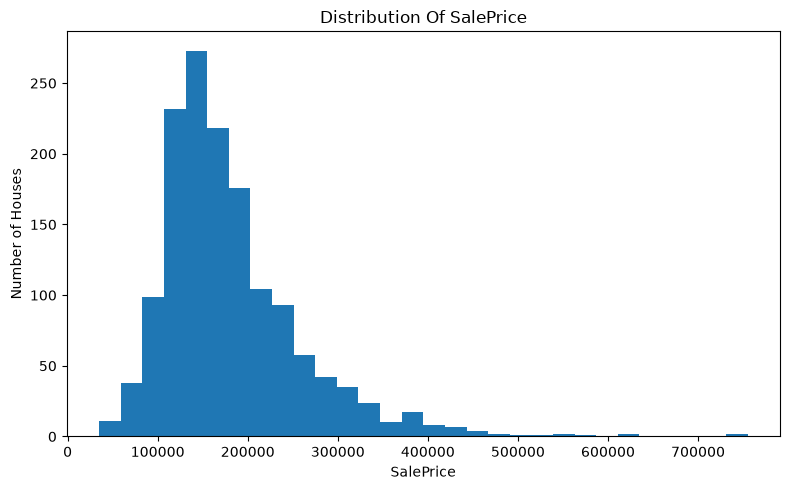

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins = 30)
plt.title("Distribution Of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("images/saleprice_distribution.png", dpi=300)
plt.show()

The distribution is right-skewed. Most houses fall within the lower and middle price ranges, while a smaller number of expensive properties form a long right tail. Because these high-priced observations may represent legitimate luxury properties, they are not automatically removed.

### Correlation Analysis

In [35]:
correlation = df.corr(numeric_only = True)
correlation["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Living Area and Sale Price

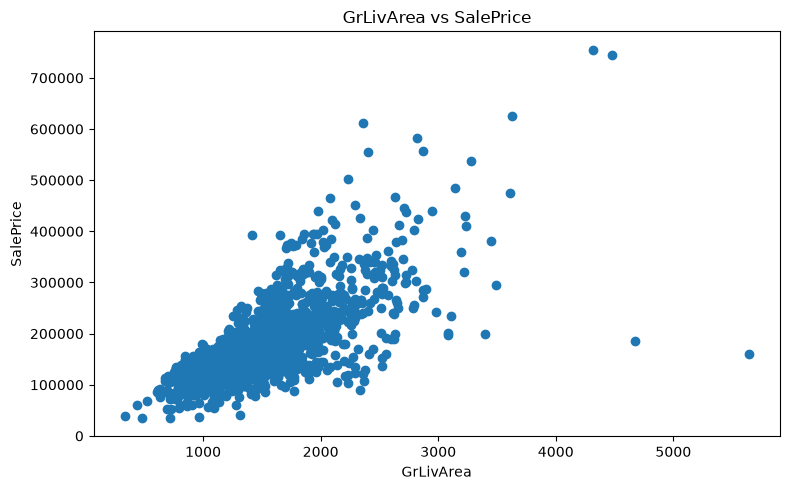

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("images/grlivarea_vs_saleprice.png", dpi=300)
plt.show()

The scatter plot shows a positive relationship between the GrLivArea and SalePrice. In general, houses with larger above-ground living areas tend to have higher sale prices. Although there are several outliers, the overall upward pattern suggests that GrLivArea is an important predictor of house price. 

### Neighborhood Price Comparison

In [37]:
avg_price = ( 
    df.groupby("Neighborhood")["SalePrice"]
     .mean()
     .sort_values(ascending= False)
)
avg_price

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

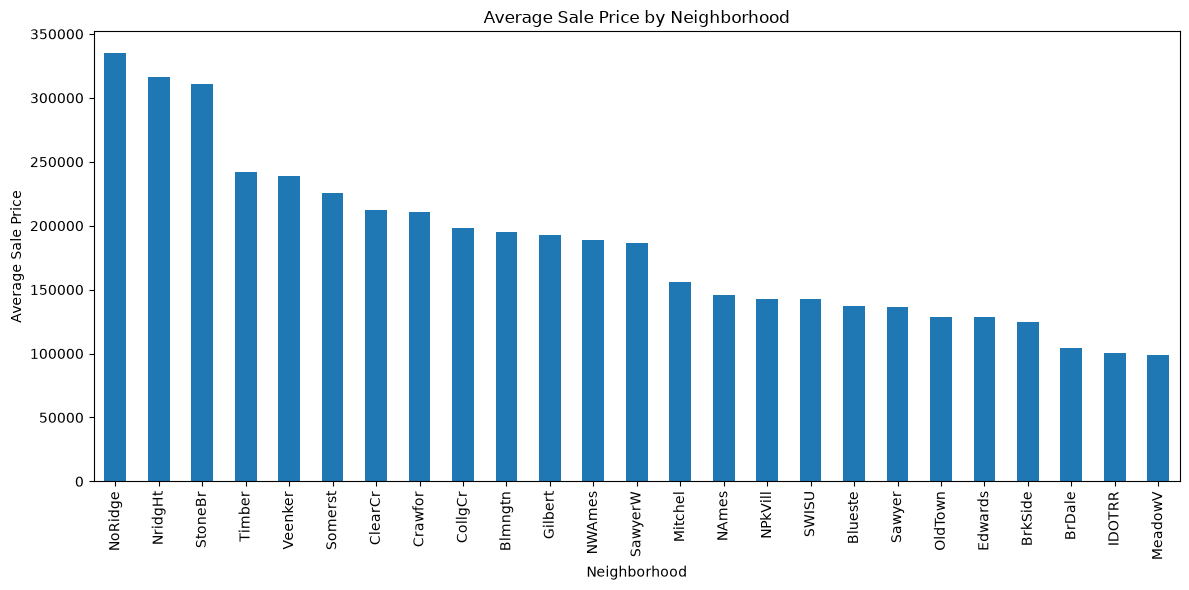

In [38]:
plt.figure(figsize=(12,6))

avg_price.plot(kind="bar")

plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")
plt.tight_layout()
plt.savefig("images/neighborhood_prices.png", dpi=300)
plt.show()

Average sale prices vary considerably across neighborhoods. NoRidge has the highest average sale price, while MeadowV has the lowest.

### Sale Price Outliers

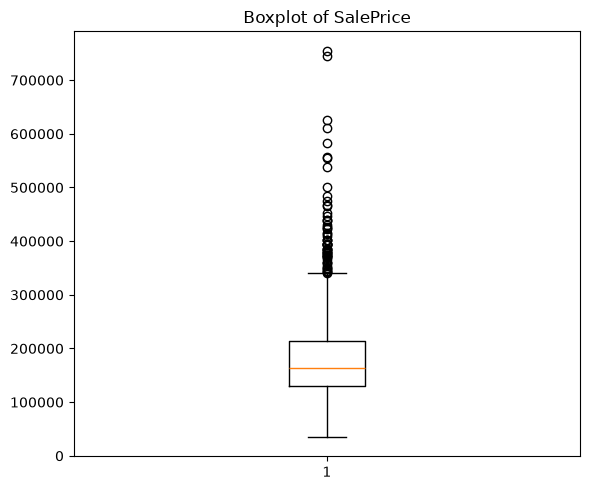

In [39]:
plt.figure(figsize=(6,5))
plt.boxplot(df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.tight_layout()
plt.savefig("images/saleprice_boxplot.png", dpi=300)
plt.show()

The box plot shows several high-priced outliers. These observations were retained because they may represent genuine high-value properties rather than data errors.

### Overall Quality and Sale Price

<function matplotlib.pyplot.show(close=None, block=None)>

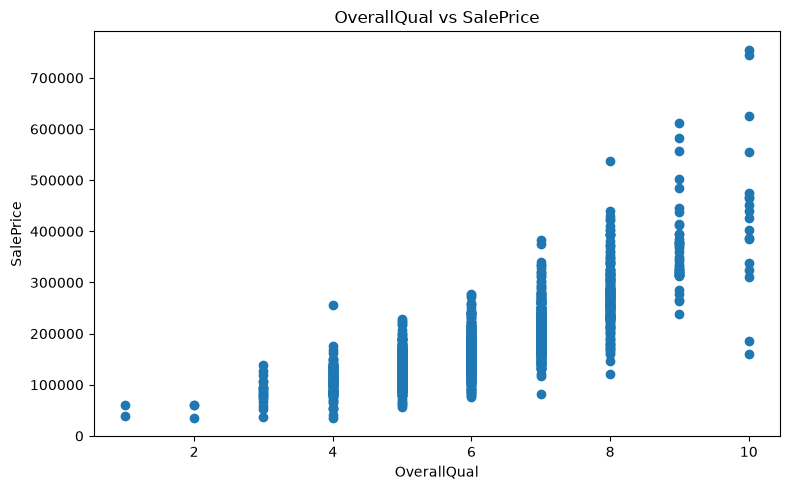

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df["OverallQual"],df["SalePrice"])
plt.title("OverallQual vs SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("images/overallqual_vs_saleprice.png", dpi=300)
plt.show

There is a strong positive relationship between OverallQual and SalePrice. Houses with higher overall-quality ratings generally sell for higher prices.

## Data Preparation

### Separate Features and Target

In [41]:
X = df.drop("SalePrice", axis = 1)
y = df["SalePrice"]

In [42]:
X.isnull().sum().sort_values(ascending=False).head(10)

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64

In [43]:
print(X.shape)
print(y.shape)

(1460, 80)
(1460,)


### Encode Categorical Variables

In [44]:
X = pd.get_dummies(X, drop_first = True)
print(X.shape)

(1460, 260)


In [66]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [46]:
X.isnull().sum().sort_values(ascending=False).head(10)

Id              0
MSSubClass      0
LotFrontage     0
LotArea         0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
MasVnrArea      0
BsmtFinSF1      0
dtype: int64

## MODEL TRAINING AND EVALUATION

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score)

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy = "mean")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = root_mean_squared_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Results:")
print(f"MAE: {baseline_mae}")
print(f"RMSE: {baseline_rmse}")
print(f"R²: {baseline_r2}")

Baseline Results:
MAE: 62575.926451960964
RMSE: 87619.03450611533
R²: -0.0008824918802490256


## Linear Regression Model

In [50]:
from sklearn.linear_model import LinearRegression

model =LinearRegression()
model.fit(X_train,y_train)

lr_predictions = model.predict(X_test)

In [51]:
print(lr_predictions[:10])

[159585.03628188 342578.11780393  82022.45862078 188053.779087
 315666.35508331  68009.44486593 251730.77448559 145349.16405893
  59777.842426   158297.28874736]


### Comparing actual vs predicted

In [52]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted": lr_predictions
})

comparison.head(10)

,Actual,Predicted
892,154500,159585.036282
1105,325000,342578.117804
413,115000,82022.458621
522,159000,188053.779087
1036,315500,315666.355083
614,75500,68009.444866
218,311500,251730.774486
1160,146000,145349.164059
649,84500,59777.842426
887,135500,158297.288747


In [53]:

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = root_mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results: ")
print(f"MAE: {lr_mae}")
print(f"RMSE: {lr_rmse}")
print(f"R2: {lr_r2}")

Linear Regression Results: 
MAE: 20303.483679478304
RMSE: 33259.371884666085
R2: 0.855783732232142


The Linear Regression model was trained using the training dataset and evaluated on the test dataset. The model achieved a Mean Absolute Error (MAE) of approximately $20,303, indicating that its predictions differed from the actual sale prices by about $20,303 on average. The Root Mean Squared Error (RMSE) was approximately $33,259, which suggests that larger prediction errors had a greater influence on the evaluation metric. The model achieved an R² score of 0.856, meaning it explained approximately 85.6% of the variation in house sale prices. Overall, the results indicate that the model performs well and provides a strong baseline for predicting house prices.


## Decision Tree Regressor

In [54]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(random_state = 42)
decision_tree.fit(X_train, y_train)
dt_predictions = decision_tree.predict(X_test)

In [55]:
dt_comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted": dt_predictions
})
dt_comparison.head(10)

,Actual,Predicted
892,154500,154000.0
1105,325000,410000.0
413,115000,108000.0
522,159000,210000.0
1036,315500,325000.0
614,75500,86000.0
218,311500,205000.0
1160,146000,148500.0
649,84500,91000.0
887,135500,112000.0


In [56]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = root_mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results: ")
print(f"MAE: {dt_mae}")
print(f"RMSE: {dt_rmse}")
print(f"R2: {dt_r2}")

Decision Tree Results: 
MAE: 26825.04109589041
RMSE: 42275.63262101289
R2: 0.766994380000135



The Decision Tree Regressor was trained and evaluated using the same training and testing datasets as the Linear Regression model. The Decision Tree achieved a Mean Absolute Error (MAE) of approximately $26,825, a Root Mean Squared Error (RMSE) of approximately $42,276, and an R² score of 0.767. Compared with the Linear Regression model, the Decision Tree produced larger prediction errors and explained less of the variation in house prices. This suggests that the Decision Tree may have overfit the training data, resulting in poorer generalization to unseen houses. Based on these results, the Linear Regression model performed better than the Decision Tree for this dataset.

## RANDOM FOREST 

Random Forest is an ensemble model that combines predictions from multiple decision trees. Averaging the trees' predictions can improve accuracy and reduce overfitting compared with using a single decision tree.

In [57]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(random_state = 42)
random_forest.fit(X_train, y_train)
rf_predictions = random_forest.predict(X_test)



In [58]:
rf_comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted": rf_predictions
})
rf_comparison.head(10)

,Actual,Predicted
892,154500,140879.25
1105,325000,326411.74
413,115000,117501.50
522,159000,154336.50
1036,315500,322854.00
614,75500,83743.00
218,311500,205540.50
1160,146000,148907.92
649,84500,83423.49
887,135500,131177.44


In [59]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = root_mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"MAE: {rf_mae}")
print(f"RMSE: {rf_rmse}")
print(f"R2: {rf_r2}")

Random Forest Results:
MAE: 17778.673116438356
RMSE: 29210.116382295797
R2: 0.8887621104995789



The Random Forest Regressor achieved the best performance among the three models evaluated. It produced a Mean Absolute Error (MAE) of approximately $17,779, a Root Mean Squared Error (RMSE) of approximately $29,210, and an R² score of 0.889. Compared with both the Linear Regression and Decision Tree models, the Random Forest generated more accurate predictions and explained a greater proportion of the variation in house sale prices. This improvement is likely due to the ensemble nature of the Random Forest algorithm, which combines the predictions of multiple decision trees to reduce overfitting and improve generalization. Based on these results, the Random Forest Regressor was selected as the best-performing model for this project.

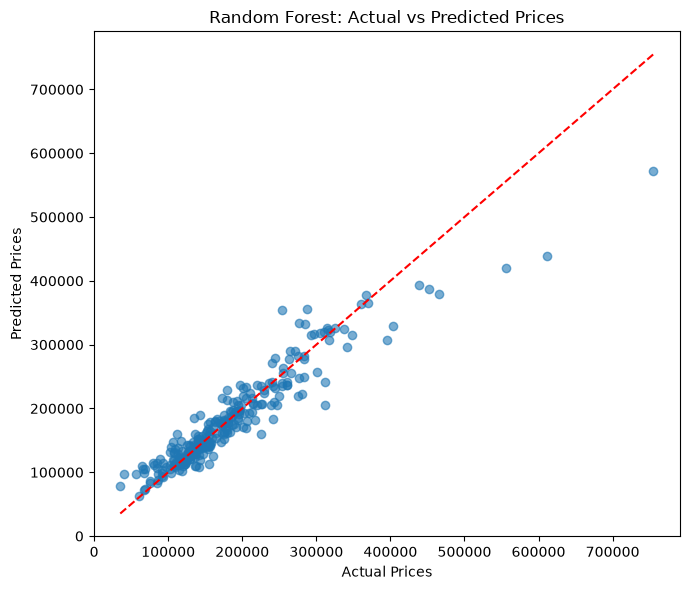

In [60]:
plt.figure(figsize =(7,6))
plt.scatter(y_test, rf_predictions, alpha = 0.6)

minimum_price = min(y_test.min(), rf_predictions.min())
maximum_price = max(y_test.max(), rf_predictions.max())

plt.plot([minimum_price, maximum_price],
        [minimum_price, maximum_price], 
        color = "red", linestyle = "--")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.tight_layout()
plt.savefig("images/random_forest_actual_vs_predicted_prices.png", dpi=300)
plt.show()


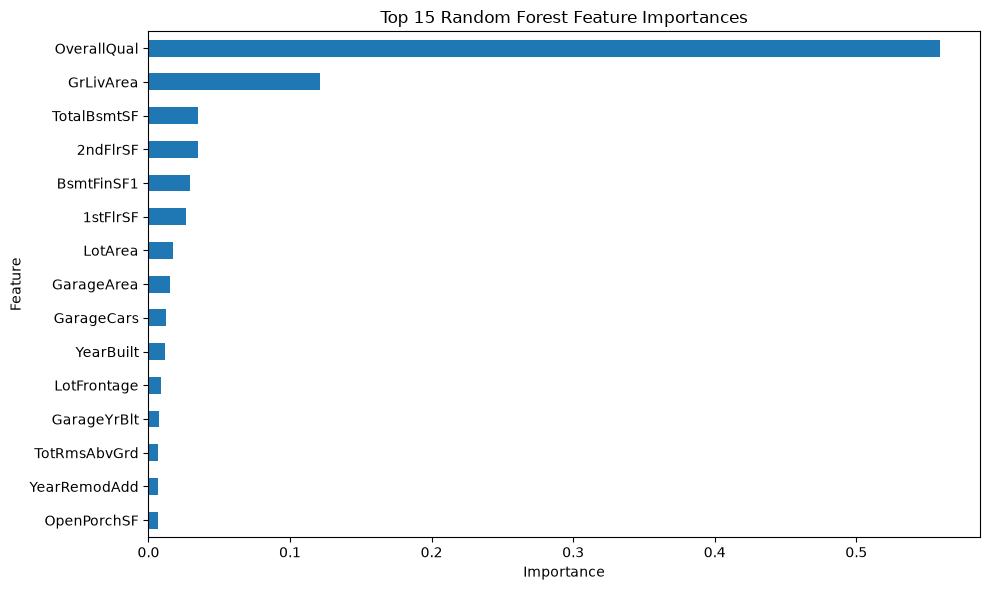

In [62]:
feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/random_forest_feature_importances.png", dpi=300)
plt.show()

The feature-importance analysis indicates which variables were most useful to the Random Forest when making predictions. Importance does not prove that a feature causes a change in sale price; it only measures how useful the model found that feature during prediction.

In [63]:
dt_train_predictions = decision_tree.predict(X_train)
rf_train_predictions = random_forest.predict(X_train)

print(
    "Decision Tree Training R²:",
    r2_score(y_train, dt_train_predictions)
)
print(
    "Decision Tree Testing R²:",
    r2_score(y_test, dt_predictions)
)

print(
    "Random Forest Training R²:",
    r2_score(y_train, rf_train_predictions)
)
print(
    "Random Forest Testing R²:",
    r2_score(y_test, rf_predictions)
)

Decision Tree Training R²: 1.0
Decision Tree Testing R²: 0.766994380000135
Random Forest Training R²: 0.9784374631543948
Random Forest Testing R²: 0.8887621104995789


The Decision Tree achieved substantially stronger performance on the training data than on the test data, indicating that it learned patterns that did not generalize as effectively to unseen houses. The Random Forest reduced this problem by averaging predictions across multiple trees.

## MODEL COMPARISON

In [64]:
comparison_model = pd.DataFrame({
    "Model":["Baseline", "Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [baseline_mae, lr_mae, dt_mae, rf_mae],
    "RMSE": [baseline_rmse, lr_rmse, dt_rmse, rf_rmse],
    "R2": [baseline_r2, lr_r2, dt_r2, rf_r2]
})
print(comparison_model)

               Model           MAE          RMSE        R2
0           Baseline  62575.926452  87619.034506 -0.000882
1  Linear Regression  20303.483679  33259.371885  0.855784
2      Decision Tree  26825.041096  42275.632621  0.766994
3      Random Forest  17778.673116  29210.116382  0.888762


## CONCLUSION

Three regression models were developed and evaluated for predicting house sale prices.

Among the models tested, the Random Forest Regressor achieved the best performance with:

- MAE: $17,779
- RMSE: $29,210
- R² Score: 0.889

The Random Forest model outperformed both the Linear Regression and Decision Tree models by producing more accurate predictions and explaining approximately 88.9% of the variation in house sale prices.

This project demonstrates the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model development, and model evaluation.

## Limitations and Future Improvements

- Performance was evaluated using a single train-test split.
- The Random Forest used mostly default hyperparameters.
- Future work could include cross-validation, hyperparameter tuning, and a log transformation of `SalePrice`.